---

# Binary Classification with a Feedforward Neural Network

A feedforward neural network (also called a multilayer perceptron) is a supervised learning model that learns complex patterns in data by passing inputs through a series of layers, each applying a weighted linear transformation followed by a nonlinear activation function.

In this notebook, we build and train a neural network from scratch to classify breast cancer tumors as malignant or benign using the Breast Cancer Wisconsin dataset. The dataset contains 30 numeric features derived from cell nucleus measurements, with a binary target variable indicating the diagnosis.

---

In [21]:
# Standard data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Our own NeuralNetwork implementation from ml_pack
from ml_pack import NeuralNetwork

# Sklearn tools for preprocessing and evaluation only
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

---

## Loading and Exploring the Data

---

In [22]:
# Load the Breast Cancer dataset
df = pd.read_csv("breast_cancer.csv")

# Check dimensions and preview
print(df.shape)
df.head()

(569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

---

## Defining Features and Target

The target variable is binary — 1 indicates benign and 0 indicates malignant. All 30 numeric columns will be used as input features.

---

In [24]:
# Separate features and target
X = df.drop(columns='target').values
y = df['target'].values

print("Feature matrix shape:", X.shape)
print("Target distribution:", dict(zip(*np.unique(y, return_counts=True))))

Feature matrix shape: (569, 30)
Target distribution: {np.int64(0): np.int64(212), np.int64(1): np.int64(357)}


---

## Splitting and Scaling the Data

We split into 80% training and 20% test sets, then standardize the features. Neural networks are sensitive to feature scale, so standardization is especially important here.

---

In [25]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features — fit on training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train_scaled.shape)
print("Test set size:", X_test_scaled.shape)

Training set size: (455, 30)
Test set size: (114, 30)


## Building the Neural Network

We use our custom NeuralNetwork class from ml_pack, which implements a feedforward network with He weight initialization, ReLU hidden activations, sigmoid output activation, and batch gradient descent.

In [26]:
def sigmoid(z):
    """Sigmoid activation function — squashes output to (0, 1)."""
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def relu(z):
    """ReLU activation — sets negative values to zero."""
    return np.maximum(0, z)

def relu_derivative(z):
    """Derivative of ReLU — 1 for positive values, 0 otherwise."""
    return (z > 0).astype(float)

def initialize_weights(layer_sizes, random_state=42):
    """
    Initialize weights and biases for each layer using He initialization.
    He initialization works well with ReLU activations.
    
    Parameters
    ----------
    layer_sizes : list of int
        Number of neurons in each layer including input and output.
    
    Returns
    -------
    list of dicts containing weights and biases for each layer.
    """
    np.random.seed(random_state)
    params = []
    for i in range(len(layer_sizes) - 1):
        W = np.random.randn(layer_sizes[i], layer_sizes[i + 1]) * np.sqrt(2 / layer_sizes[i])
        b = np.zeros((1, layer_sizes[i + 1]))
        params.append({'W': W, 'b': b})
    return params

---

## Training the Network

We train the network using batch gradient descent for 1000 epochs. The architecture is:
- Input layer: 30 neurons (one per feature)
- Hidden layer 1: 64 neurons with ReLU
- Hidden layer 2: 32 neurons with ReLU
- Output layer: 1 neuron with sigmoid

---

In [27]:
# Initialize and train our custom neural network
model = NeuralNetwork(hidden_layers=[64, 32], learning_rate=0.01, epochs=1000, random_state=42)
model.fit(X_train_scaled, y_train)

---

## Evaluating the Model

---

              precision    recall  f1-score   support

   Malignant       0.98      0.95      0.96        43
      Benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



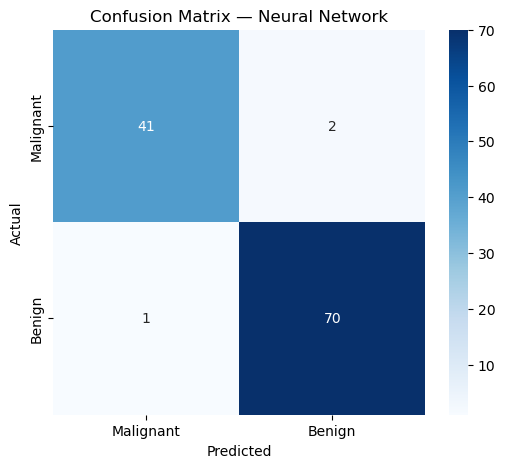

In [28]:
# Generate predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)

# Print classification report
print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Neural Network")
plt.show()

---

## ROC Curve

The ROC curve plots the true positive rate against the false positive rate at various classification thresholds. The area under the curve (AUC) summarizes overall model performance — a perfect classifier has an AUC of 1.0.

---

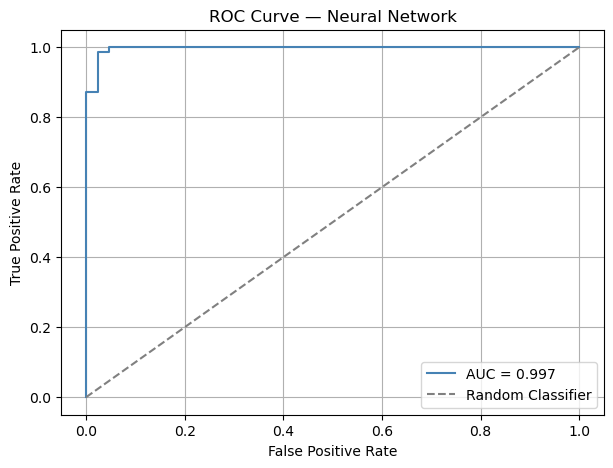

In [29]:
from sklearn.metrics import roc_curve, roc_auc_score

# Compute ROC curve and AUC score
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Neural Network")
plt.legend()
plt.grid(True)
plt.show()

---

## Training Loss Over Time

Let's visualize how the loss decreased over training to confirm the network converged properly.

---

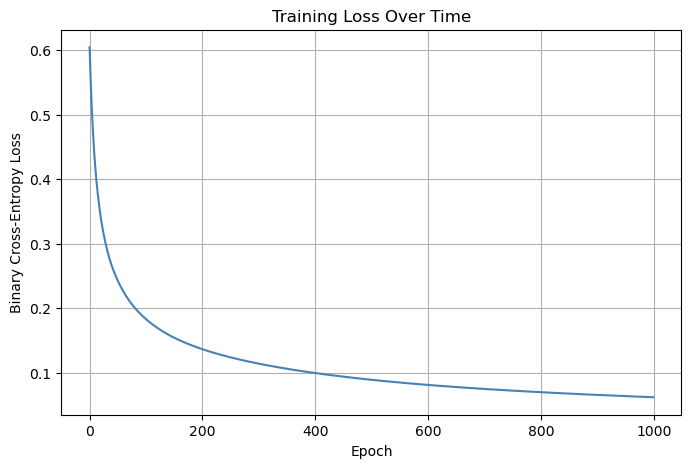

In [30]:
# Plot training loss over epochs
plt.figure(figsize=(8, 5))
plt.plot(model.loss_history, color='steelblue')
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Training Loss Over Time")
plt.grid(True)
plt.show()

---

## Summary

In this notebook, we built a feedforward neural network from scratch using NumPy to classify breast cancer tumors as malignant or benign. The network achieved 97% accuracy on the test set after 1000 training epochs.

Key takeaways:
- Neural networks learn by repeatedly adjusting weights through backpropagation to minimize the loss
- ReLU activation in hidden layers helps avoid the vanishing gradient problem
- Sigmoid activation in the output layer maps predictions to a probability between 0 and 1
- Standardizing features before training is critical for neural networks to converge properly
- The training loss curve confirms the network converged smoothly without overfitting

---